# CIFAR-10 RGB v3 — Custom Residual CNN + SVM Training

Use only the official 50,000-image development split: 40,000 for fitting and 10,000 for validation and model selection. The official test split is reserved for `RGB Testing.ipynb`. Outputs are `cifar10_custom_cnn_v3.keras` and `cifar10_svm_v3.joblib`.


In [1]:
import os
import gc
import time
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

SEED = 30092026
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf

for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass
tf.random.set_seed(SEED)
tf.keras.mixed_precision.set_global_policy("mixed_float16")

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    Activation,
    Add,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    PredefinedSplit,
)
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

print("GPU:", tf.config.list_physical_devices("GPU"))
print("Mixed precision:", tf.keras.mixed_precision.global_policy())

I0000 00:00:1791384021.044827   31494 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791384021.081763   31494 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791384022.085436   31494 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision: <DTypePolicy "mixed_float16">


## 1. Load CIFAR-10

CIFAR-10 berisi 60.000 gambar RGB berukuran 32×32 pada 10 kelas.

Notebook training hanya mengambil **50.000 training images resmi CIFAR-10**.  
10.000 test images disimpan untuk notebook testing.


In [2]:
# Di notebook training ini kita hanya mengambil official_train.
# Official test split dibuang dengan `_` dan tidak dipakai sama sekali.
(X_train_full, y_train_full), _ = cifar10.load_data()

labels = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

classes_name = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck",
]

print("Official CIFAR-10 training images:", X_train_full.shape)
print("Official CIFAR-10 training labels:", y_train_full.shape)

Official CIFAR-10 training images: (50000, 32, 32, 3)
Official CIFAR-10 training labels: (50000, 1)


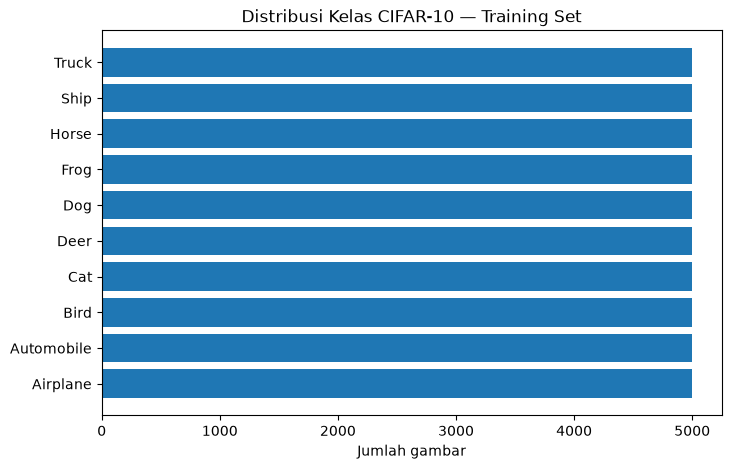

In [3]:
classes, counts = np.unique(y_train_full, return_counts=True)

plt.figure(figsize=(8, 5))
plt.barh(classes_name, counts)
plt.title("Distribusi Kelas CIFAR-10 — Training Set")
plt.xlabel("Jumlah gambar")
plt.show()

## 2. Tampilkan Contoh Gambar CIFAR-10


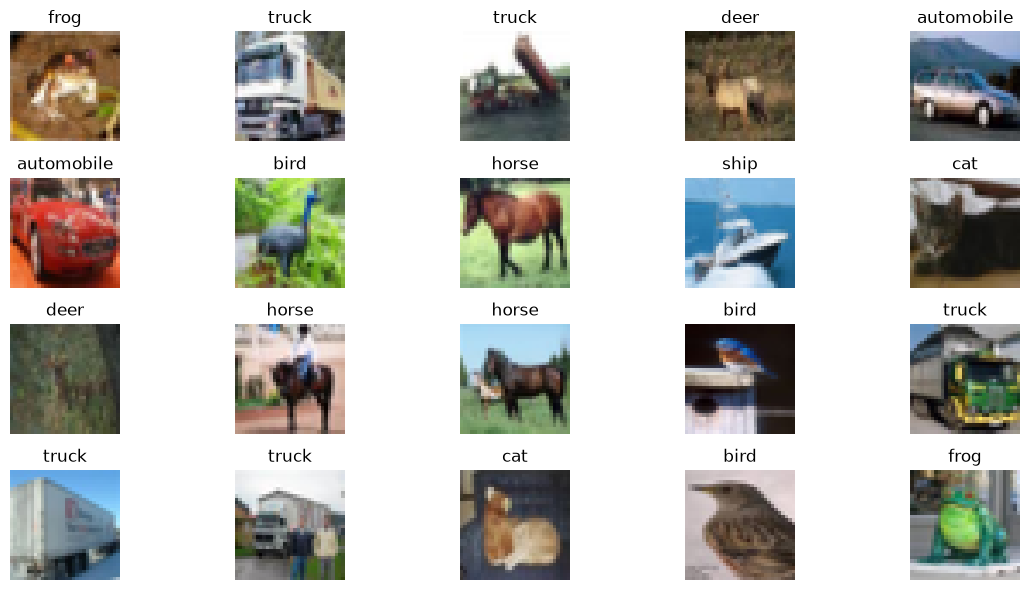

In [4]:
plt.figure(figsize=(12, 6))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_train_full[i])
    plt.title(labels[int(y_train_full[i, 0])])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Preprocessing dan Train/Validation Split

`cifar10.load_data()` menyediakan dua official split:

```text
50.000 official training images
10.000 official test images
```

Notebook ini **hanya mengambil 50.000 official training images**.

Dari 50.000 training images tersebut dibuat:

- **40.000 training images** untuk gradient update pada `model.fit()`
- **10.000 validation images** untuk menghitung `val_loss` dan `val_accuracy`

Validation set tidak digunakan oleh optimizer untuk memperbarui bobot.

Preprocessing:

- normalisasi pixel `0..255 → 0..1`
- stratified split
- `random_state = 30092026`


In [5]:
# Normalisasi hanya official training split.
X_train_full = X_train_full.astype("float32") / 255.0
y_train_full = y_train_full.flatten()

# Validation diambil dari official training split.
# X_val/y_val TIDAK digunakan untuk gradient update.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=SEED, stratify=y_train_full
)

y_cat_train = to_categorical(y_train, 10)
y_cat_val = to_categorical(y_val, 10)

print("Training data   :", X_train.shape, y_train.shape)
print("Validation data :", X_val.shape, y_val.shape)
print()
print("Data yang benar-benar digunakan model.fit() untuk update bobot:")
print("X_train =", X_train.shape)
print("y_train =", y_train.shape)

Training data   : (40000, 32, 32, 3) (40000,)
Validation data : (10000, 32, 32, 3) (10000,)

Data yang benar-benar digunakan model.fit() untuk update bobot:
X_train = (40000, 32, 32, 3)
y_train = (40000,)


## 4. Custom residual CNN

Four residual stages (64, 128, 256, 512 channels) preserve spatial information before global average pooling. The 512-dimensional `svm_features` layer is **signed**: its output is batch-normalized without ReLU, avoiding dead embedding channels. All weights are trained from scratch.


In [6]:
INPUT_SHAPE = (32, 32, 3)
BATCH_SIZE = 128
MAX_EPOCHS = 100
INITIAL_LR = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT_RATE = 0.30


def residual_block(x, filters, stride, name):
    shortcut = x
    x = Conv2D(
        filters, 3, strides=stride, padding="same", use_bias=False, name=f"{name}_conv1"
    )(x)
    x = BatchNormalization(name=f"{name}_bn1")(x)
    x = Activation("relu", name=f"{name}_relu1")(x)
    x = Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_conv2")(x)
    x = BatchNormalization(name=f"{name}_bn2")(x)
    if stride != 1 or int(shortcut.shape[-1]) != filters:
        shortcut = Conv2D(
            filters,
            1,
            strides=stride,
            padding="same",
            use_bias=False,
            name=f"{name}_shortcut_conv",
        )(shortcut)
        shortcut = BatchNormalization(name=f"{name}_shortcut_bn")(shortcut)
    x = Add(name=f"{name}_add")([x, shortcut])
    return Activation("relu", name=f"{name}_out")(x)


def build_custom_cnn(
    initial_lr=INITIAL_LR,
    weight_decay=WEIGHT_DECAY,
    dropout_rate=DROPOUT_RATE,
    epochs=MAX_EPOCHS,
    training_samples=None,
    batch_size=BATCH_SIZE,
):
    inputs = Input(shape=INPUT_SHAPE, name="input_image")
    x = Conv2D(64, 3, padding="same", use_bias=False, name="stem_conv")(inputs)
    x = BatchNormalization(name="stem_bn")(x)
    x = Activation("relu", name="stem_relu")(x)

    for stage, filters in enumerate((64, 128, 256, 512), start=1):
        x = residual_block(x, filters, 1 if stage == 1 else 2, f"stage{stage}_block1")
        x = residual_block(x, filters, 1, f"stage{stage}_block2")
    
    feature_map = Activation("linear", name="feature_map")(x)
    pooled = GlobalAveragePooling2D(name="global_pool")(feature_map)
    projection = Dense(512, use_bias=False, name="embedding_dense")(pooled)
    embedding = BatchNormalization(name="svm_features", dtype="float32")(projection)
    head = Dropout(dropout_rate, seed=SEED, name="classifier_dropout")(embedding)
    
    outputs = Dense(10, activation="softmax", dtype="float32", name="cnn_softmax")(head)
    
    model = Model(inputs, outputs, name="custom_cifar10_rgb_residual_v3")
    
    steps = int(np.ceil((len(X_train) if training_samples is None else training_samples) / batch_size)) * epochs
    schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_lr, decay_steps=steps, alpha=0.01
    )
    
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=schedule, weight_decay=weight_decay
        ),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=["accuracy"],
    )
    return model

In [7]:
# The final model is constructed once in the training section.
print("Architecture: CIFAR residual CNN with a signed 512-D embedding")

Architecture: CIFAR residual CNN with a signed 512-D embedding


## 5. Training augmentation

Augmentation is applied only to training images. Validation and test images use normalized pixels without random transforms.


In [8]:
data_generator = ImageDataGenerator(
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.10,
    fill_mode="reflect",
)

## 6. GridSearchCV for custom CNN settings

GridSearchCV evaluates four custom residual CNN configurations using a stratified 15,000-image subset of the 40,000 training rows.

The held-out 10,000 validation rows are used only to score each candidate through an RBF-SVM probe trained on the CNN embedding. They are not used for CNN gradient updates.

Search parameters:
- `initial_lr`: 0.001 and 0.0003
- `dropout_rate`: 0.30 and 0.50
- `weight_decay`: fixed at 0.0001
- maximum search epochs: 30
- batch size: 128

After selection, the winning configuration is trained again from scratch using all 40,000 training rows for up to 100 epochs.

In [9]:
print("Training rows:", len(X_train))
print("Validation rows:", len(X_val))
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", MAX_EPOCHS)

Training rows: 40000
Validation rows: 10000
Batch size: 128
Maximum epochs: 100


### CNN search configuration and sklearn-compatible estimator

This cell defines the reduced hyperparameter space and the custom estimator used by `GridSearchCV`. Weight decay is fixed so the search remains computationally manageable.

In [10]:
CNN_GRID = {
    "initial_lr": (1e-3, 3e-4),
    "dropout_rate": (0.30, 0.50),
}

SEARCH_EPOCHS = 30
CNN_SEARCH_SAMPLES = 15000

# weight_decay is intentionally fixed, not searched.
SEARCH_WEIGHT_DECAY = WEIGHT_DECAY
CNN_MODEL_PATH = "models/cifar10_custom_cnn_v3.keras"

class CNNEmbeddingSearchEstimator(
    ClassifierMixin,
    BaseEstimator,
):
    def __init__(
        self,
        initial_lr=INITIAL_LR,
        dropout_rate=DROPOUT_RATE,
        weight_decay=SEARCH_WEIGHT_DECAY,
        search_epochs=SEARCH_EPOCHS,
        batch_size=BATCH_SIZE,
    ):
        self.initial_lr = initial_lr
        self.dropout_rate = dropout_rate
        self.weight_decay = weight_decay
        self.search_epochs = search_epochs
        self.batch_size = batch_size

    def fit(self, X, y):
        # Release the previous Keras graph before creating another candidate.
        tf.keras.backend.clear_session()
        gc.collect()

        tf.random.set_seed(SEED)
        np.random.seed(SEED)
        random.seed(SEED)

        self.classes_ = np.unique(y)

        self.cnn_model_ = build_custom_cnn(
            initial_lr=self.initial_lr,
            weight_decay=self.weight_decay,
            dropout_rate=self.dropout_rate,
            epochs=self.search_epochs,
            training_samples=len(X),
            batch_size=self.batch_size,
        )

        generator = data_generator.flow(
            X,
            to_categorical(y, 10),
            batch_size=self.batch_size,
            shuffle=True,
            seed=SEED,
        )

        # verbose=1 gives visible progress for every epoch.
        self.cnn_model_.fit(
            generator,
            epochs=self.search_epochs,
            verbose=1,
        )

        self.extractor_ = Model(
            self.cnn_model_.input,
            self.cnn_model_.get_layer(
                "svm_features"
            ).output,
        )

        train_features = self.extractor_.predict(
            X,
            batch_size=128,
            verbose=1,
        ).astype(np.float32)

        assert np.isfinite(
            train_features
        ).all()

        self.probe_ = Pipeline(
            [
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "svm",
                    SVC(
                        kernel="rbf",
                        C=10,
                        gamma="scale",
                        cache_size=2048,
                    ),
                ),
            ]
        )

        self.probe_.fit(
            train_features,
            y,
        )

        return self

    def predict(self, X):
        features = self.extractor_.predict(
            X,
            batch_size=128,
            verbose=0,
        ).astype(np.float32)

        return self.probe_.predict(
            features
        )

    def score(self, X, y):
        return accuracy_score(
            y,
            self.predict(X),
        )


CNN_GRID_CANDIDATES = (
    len(CNN_GRID["initial_lr"])
    * len(CNN_GRID["dropout_rate"])
)

print(
    "CNN GridSearchCV candidates:",
    CNN_GRID_CANDIDATES,
)
print(
    "CNN search training samples:",
    CNN_SEARCH_SAMPLES,
)
print(
    "Search epochs per candidate:",
    SEARCH_EPOCHS,
)
print(
    "Search/final batch size:",
    BATCH_SIZE,
)
print(
    "Fixed weight decay:",
    SEARCH_WEIGHT_DECAY,
)
print(
    "Final training maximum epochs:",
    MAX_EPOCHS,
)

CNN GridSearchCV candidates: 4
CNN search training samples: 15000
Search epochs per candidate: 30
Search/final batch size: 128
Fixed weight decay: 0.0001
Final training maximum epochs: 100


## 7. Train RGB CNN and save the best validation checkpoint


In [11]:
# ================================================================
# 1. Build a deterministic stratified 15K subset from X_train only
# ================================================================

all_train_indices = np.arange(len(X_train))

cnn_search_indices, _ = train_test_split(
    all_train_indices,
    train_size=CNN_SEARCH_SAMPLES,
    random_state=SEED,
    stratify=y_train,
)

X_cnn_search_train = X_train[cnn_search_indices]
y_cnn_search_train = y_train[cnn_search_indices]

print("CNN search training data :", X_cnn_search_train.shape)
print("CNN search validation    :", X_val.shape)

assert len(X_cnn_search_train) == CNN_SEARCH_SAMPLES


# ================================================================
# 2. Prepare a fixed train/validation split for GridSearchCV
#
# -1 = training rows
#  0 = validation rows
#
# Validation data is NEVER used for CNN gradient updates.
# ================================================================

X_cnn_search = np.concatenate(
    (
        X_cnn_search_train,
        X_val,
    ),
    axis=0,
)

y_cnn_search = np.concatenate(
    (
        y_cnn_search_train,
        y_val,
    ),
    axis=0,
)

cnn_validation_split = PredefinedSplit(
    test_fold=np.concatenate(
        (
            np.full(
                len(y_cnn_search_train),
                -1,
                dtype=int,
            ),
            np.zeros(
                len(y_val),
                dtype=int,
            ),
        )
    )
)

print("\nGridSearchCV input:")
print("Total rows :", X_cnn_search.shape[0])
print(
    "Train rows:",
    np.sum(cnn_validation_split.test_fold == -1),
)
print(
    "Val rows  :",
    np.sum(cnn_validation_split.test_fold == 0),
)


# ================================================================
# 3. Run CNN GridSearchCV
# ================================================================

cnn_search = GridSearchCV(
    estimator=CNNEmbeddingSearchEstimator(
        weight_decay=SEARCH_WEIGHT_DECAY,
        search_epochs=SEARCH_EPOCHS,
        batch_size=BATCH_SIZE,
    ),
    param_grid=CNN_GRID,
    cv=cnn_validation_split,
    scoring=None,
    refit=False,
    n_jobs=1,
    error_score="raise",
    verbose=2,
)

cnn_search.fit(
    X_cnn_search,
    y_cnn_search,
)


# ================================================================
# 4. Read and display GridSearchCV results
# ================================================================

best_cnn_config = cnn_search.best_params_.copy()

# weight_decay is fixed rather than searched,
# so add it manually to the winning configuration.
best_cnn_config["weight_decay"] = SEARCH_WEIGHT_DECAY

best_probe_accuracy = float(
    cnn_search.best_score_
)

grid_results = pd.DataFrame(
    [
        {
            **params,
            "weight_decay": SEARCH_WEIGHT_DECAY,
            "svm_probe_val_accuracy": float(score),
        }
        for params, score in zip(
            cnn_search.cv_results_["params"],
            cnn_search.cv_results_["mean_test_score"],
        )
    ]
).sort_values(
    "svm_probe_val_accuracy",
    ascending=False,
).reset_index(drop=True)

display(grid_results)

print("\nSelected CNN configuration:")
print(best_cnn_config)

print(
    "\nBest SVM-probe validation accuracy:",
    f"{best_probe_accuracy:.4%}",
)


# ================================================================
# 5. Clean GridSearch objects before final CNN training
# ================================================================

del cnn_search
del X_cnn_search
del y_cnn_search
del X_cnn_search_train
del y_cnn_search_train

tf.keras.backend.clear_session()
gc.collect()

print("\nGridSearch objects cleared from memory.")


# ================================================================
# 6. Reset random seeds before final CNN training
# ================================================================

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

CNN search training data : (15000, 32, 32, 3)
CNN search validation    : (10000, 32, 32, 3)

GridSearchCV input:
Total rows : 25000
Train rows: 15000
Val rows  : 10000
Fitting 1 folds for each of 4 candidates, totalling 4 fits


I0000 00:00:1791384025.544879   31494 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3672 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/30


I0000 00:00:1791384026.383040   31494 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1791384032.250493   31571 service.cc:153] XLA service 0x701db803ccd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791384032.250524   31571 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1791384032.443173   31571 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1791384033.713486   31571 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1791384033.873763   31571 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16616__.144
I0000 00:00:1791384037.607941   31643 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusio

  1/118 ━━━━━━━━━━━━━━━━━━━━ 45:24 23s/step - accuracy: 0.0938 - loss: 3.5399

...

 53/118 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.2776 - loss: 2.3184

I0000 00:00:1791385246.256455   31573 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_119870__.144


118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 152ms/step - accuracy: 0.3309 - loss: 2.1073
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - accuracy: 0.4563 - loss: 1.7217
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - accuracy: 0.4865 - loss: 1.6862
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - accuracy: 0.5373 - loss: 1.5083
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - accuracy: 0.5813 - loss: 1.4149
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - accuracy: 0.6090 - loss: 1.3345
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - accuracy: 0.6351 - loss: 1.2653
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 103ms/step - accuracy: 0.6383 - loss: 1.2601
Epoch 9/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - accuracy: 0.6750 - loss: 1.1587
Epoch 10/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - accuracy: 0.6930 - loss: 1.1252
Epoch 11/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - accuracy: 0.7254 - loss: 1.0312
Epoch 12/30
118/118 ━━━━━━━━━━

,dropout_rate,initial_lr,weight_decay,svm_probe_val_accuracy
0,0.3,0.0010,0.0001,0.8512
1,0.5,0.0010,0.0001,0.8409
2,0.3,0.0003,0.0001,0.8357
3,0.5,0.0003,0.0001,0.8203



Selected CNN configuration:
{'dropout_rate': 0.3, 'initial_lr': 0.001, 'weight_decay': 0.0001}

Best SVM-probe validation accuracy: 85.1200%

GridSearch objects cleared from memory.


In [12]:
# ================================================================
# 7. Build the final CNN using the winning configuration
#
# Final CNN is trained FROM SCRATCH using all 40K training rows.
# ================================================================

model = build_custom_cnn(
    **best_cnn_config,
    epochs=MAX_EPOCHS,
    training_samples=len(X_train),
    batch_size=BATCH_SIZE,
)

print("\nFinal CNN configuration:")
print("Training samples :", len(X_train))
print("Validation       :", len(X_val))
print("Batch size       :", BATCH_SIZE)
print("Maximum epochs   :", MAX_EPOCHS)
print("Parameters       :", best_cnn_config)


# ================================================================
# 8. Create augmented training generator
# ================================================================

train_generator = data_generator.flow(
    X_train,
    y_cat_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)


# ================================================================
# 9. Final-training callbacks
#
# ModelCheckpoint saves the CNN with the highest validation accuracy.
#
# EarlyStopping prevents unnecessary training after validation
# accuracy stops improving.
#
# Learning rate is already controlled by CosineDecay inside
# build_custom_cnn(), so ReduceLROnPlateau is intentionally not used.
# ================================================================

callbacks = [
    ModelCheckpoint(
        CNN_MODEL_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),

    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=15,
        restore_best_weights=True,
        verbose=1,
    ),

]


# ================================================================
# 10. Train final CNN
# ================================================================

started = time.time()

history = model.fit(
    train_generator,
    epochs=MAX_EPOCHS,
    validation_data=(
        X_val,
        y_cat_val,
    ),
    callbacks=callbacks,
    verbose=1,
)

final_training_seconds = time.time() - started


# ================================================================
# 11. Summarize final CNN training
# ================================================================

best_epoch = int(
    np.argmax(
        history.history["val_accuracy"]
    ) + 1
)

best_val_accuracy = float(
    np.max(
        history.history["val_accuracy"]
    )
)

print("\n" + "=" * 80)
print("FINAL CNN TRAINING SUMMARY")
print("=" * 80)

print(
    "Best epoch:",
    best_epoch,
)

print(
    "Best validation accuracy:",
    f"{best_val_accuracy:.4%}",
)

print(
    "Training time:",
    f"{final_training_seconds:.1f} seconds",
)

print(
    "Best CNN saved to:",
    CNN_MODEL_PATH,
)


Final CNN configuration:
Training samples : 40000
Validation       : 10000
Batch size       : 128
Maximum epochs   : 100
Parameters       : {'dropout_rate': 0.3, 'initial_lr': 0.001, 'weight_decay': 0.0001}
Epoch 1/100


I0000 00:00:1791385632.536178   31572 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_154288__.144


105/313 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - accuracy: 0.3219 - loss: 2.0675

I0000 00:00:1791385648.951403   31573 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_154288__.144
I0000 00:00:1791385650.935966   39891 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 4 bytes spill stores, 4 bytes spill loads



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.4126 - loss: 1.8023
Epoch 1: val_accuracy improved from None to 0.19850, saving model to models/cifar10_custom_cnn_v3.keras

Epoch 1: finished saving model to models/cifar10_custom_cnn_v3.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 65s 172ms/step - accuracy: 0.4126 - loss: 1.8023 - val_accuracy: 0.1985 - val_loss: 2.8732
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.5684 - loss: 1.4161
Epoch 2: val_accuracy improved from 0.19850 to 0.49830, saving model to models/cifar10_custom_cnn_v3.keras

Epoch 2: finished saving model to models/cifar10_custom_cnn_v3.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.5684 - loss: 1.4161 - val_accuracy: 0.4983 - val_loss: 1.6389
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.6474 - loss: 1.2255
Epoch 3: val_accuracy improved from 0.49830 to 0.57220, saving model to models/cifar10_custom_cnn_v3.keras

Epoch 3: finished saving model to models/cifar10

## 8. Training Curve


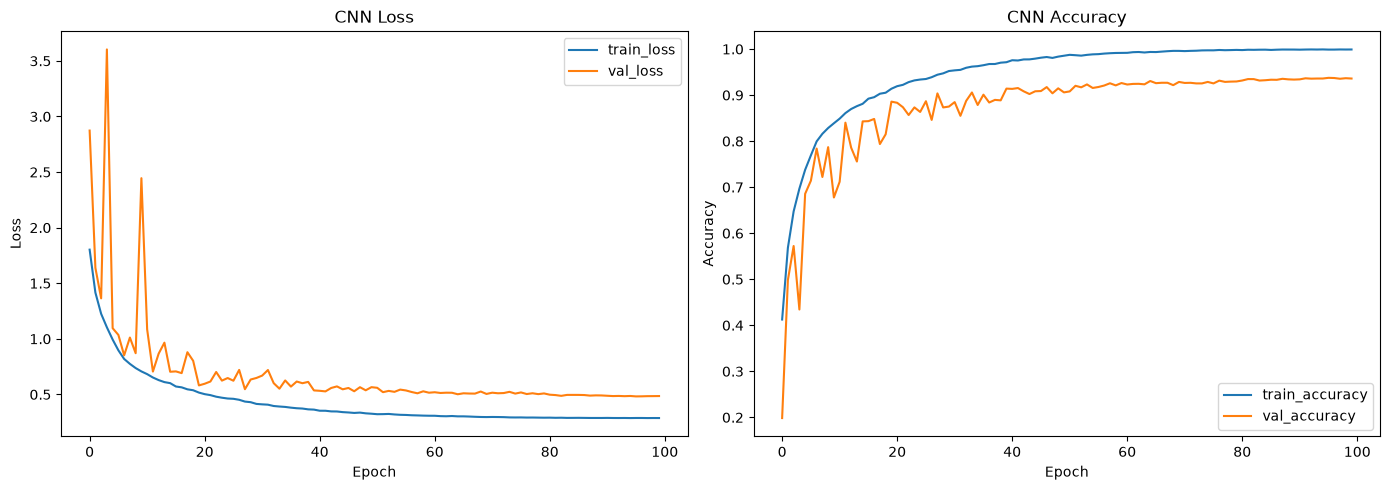

Best epoch: 96
Best validation accuracy during training: 93.75%


In [13]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

best_epoch = int(history_df["val_accuracy"].idxmax() + 1)
best_val_history = float(history_df["val_accuracy"].max())

print("Best epoch:", best_epoch)
print(f"Best validation accuracy during training: {best_val_history * 100:.2f}%")

## 9. Load CNN Terbaik

Seluruh proses feature extraction berikutnya menggunakan checkpoint CNN dengan validation accuracy terbaik.


In [14]:
best_cnn = load_model(CNN_MODEL_PATH)

cnn_val_loss, cnn_val_accuracy = best_cnn.evaluate(X_val, y_cat_val, verbose=1)

print(f"CNN validation loss    : {cnn_val_loss:.4f}")
print(f"CNN validation accuracy: {cnn_val_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9375 - loss: 0.4824
CNN validation loss    : 0.4824
CNN validation accuracy: 93.75%


## 10. Visualize selected CNN feature maps on a validation image


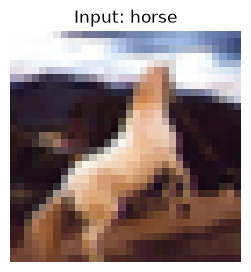

stem_relu: (1, 32, 32, 64)


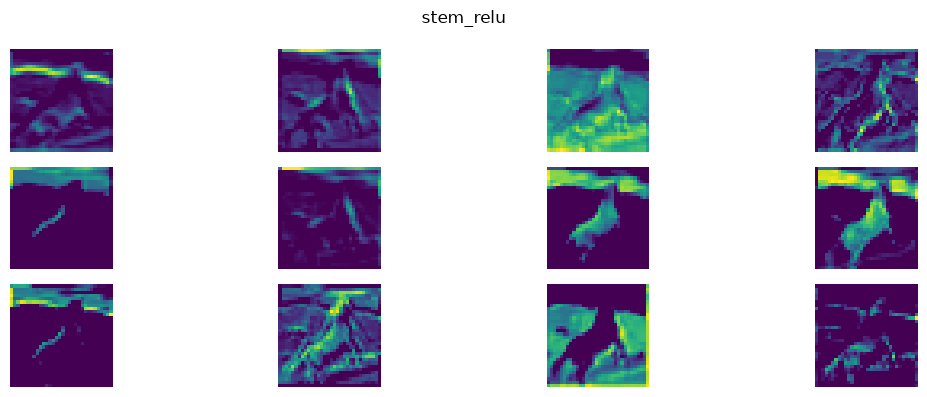

stage2_block2_out: (1, 16, 16, 128)


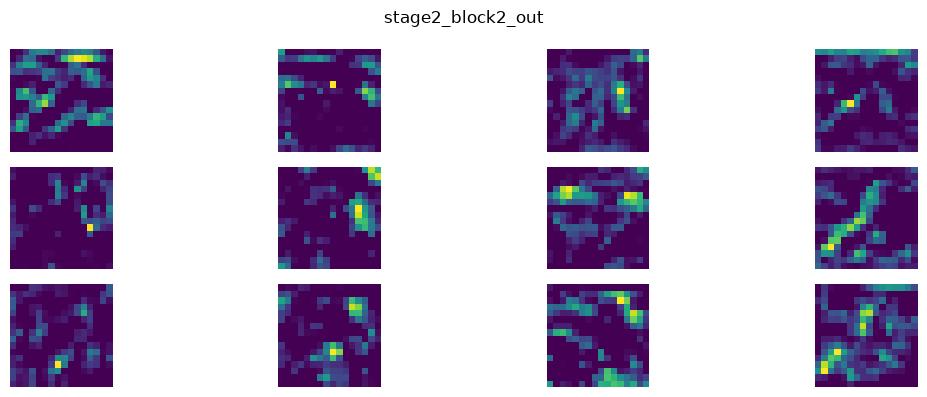

stage3_block2_out: (1, 8, 8, 256)


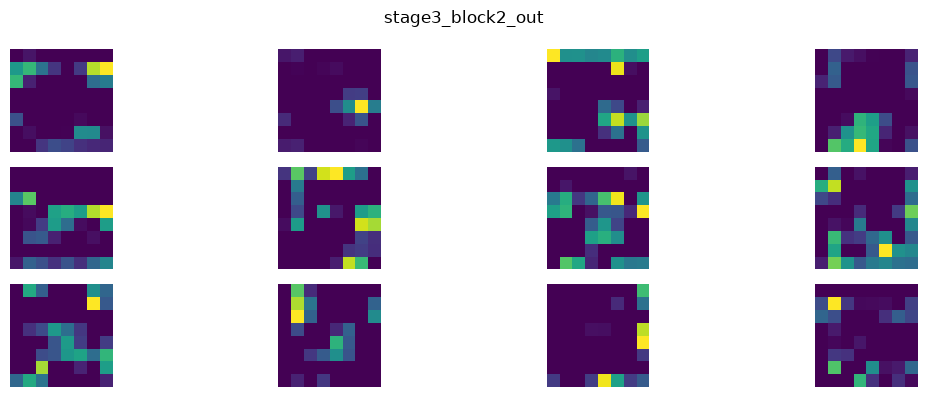

feature_map: (1, 4, 4, 512)


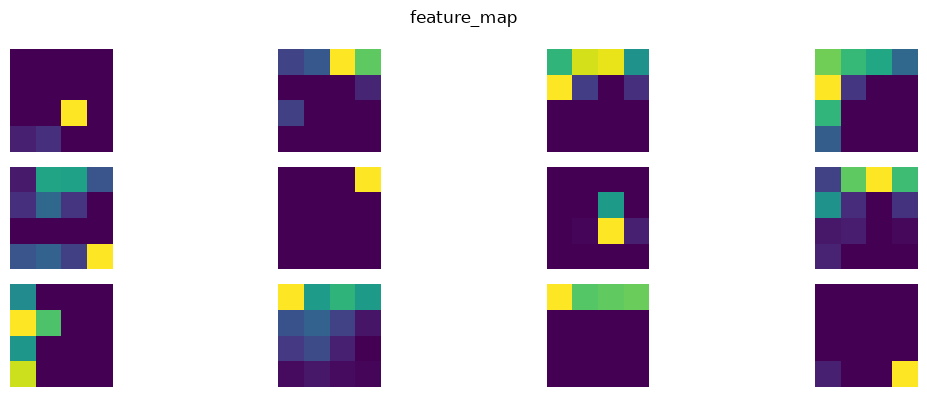

In [15]:
FEATURE_MAP_LAYERS = [
    "stem_relu",
    "stage2_block2_out",
    "stage3_block2_out",
    "feature_map",
]
feature_map_model = Model(
    best_cnn.input, [best_cnn.get_layer(name).output for name in FEATURE_MAP_LAYERS]
)
sample_index = 0
sample_image = X_val[sample_index : sample_index + 1]
feature_maps = feature_map_model.predict(sample_image, verbose=0)
plt.figure(figsize=(3, 3))
plt.imshow(sample_image[0])
plt.title(f"Input: {labels[y_val[sample_index]]}")
plt.axis("off")
plt.show()
for layer_name, fmap in zip(FEATURE_MAP_LAYERS, feature_maps):
    n_show = min(12, fmap.shape[-1])
    print(f"{layer_name}: {fmap.shape}")
    plt.figure(figsize=(12, 4))
    for i in range(n_show):
        plt.subplot(3, 4, i + 1)
        plt.imshow(fmap[0, :, :, i], cmap="viridis")
        plt.axis("off")
    plt.suptitle(layer_name)
    plt.tight_layout()
    plt.show()

## 11. Extract signed RGB embeddings for the individual SVM

Use the named `svm_features` layer (512 values) from the best validation checkpoint. These features are also extracted for all splits by `RGB Extraction.ipynb`.


In [16]:
feature_extractor = Model(
    inputs=best_cnn.input,
    outputs=best_cnn.get_layer("svm_features").output,
    name="cnn_feature_extractor",
)

feature_extractor.summary()

Model: "cnn_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 32, 32,    │      1,728 │ input_image[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 32, 32,    │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu           │ (None, 32, 32,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv1 │ (None, 32, 32,    │     36,864 │ stem_relu[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn1   │ (None, 32, 32,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu1 │ (None, 32, 32,    │          0 │ stage1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv2 │ (None, 32, 32,    │     36,864 │ stage1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn2   │ (None, 32, 32,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_add   │ (None, 32, 32,    │          0 │ stage1_block1_bn… │
│ (Add)               │ 64)               │            │ stem_relu[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_out   │ (None, 32, 32,    │          0 │ stage1_block1_ad… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv1 │ (None, 32, 32,    │     36,864 │ stage1_block1_ou… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn1   │ (None, 32, 32,    │        256 │ stage1_block2_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_relu1 │ (None, 32, 32,    │          0 │ stage1_block2_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv2 │ (None, 32, 32,    │     36,864 │ stage1_block2_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn2   │ (None, 32, 32,    │        256 │ stage1_block2_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_add   │ (None, 32, 32,    │          0 │ stage1_block2_bn

 Total params: 11,442,624 (43.65 MB)

 Trainable params: 11,432,000 (43.61 MB)

 Non-trainable params: 10,624 (41.50 KB)

In [17]:
X_train_features = feature_extractor.predict(X_train, batch_size=128, verbose=1).astype(
    np.float32
)
X_val_features = feature_extractor.predict(X_val, batch_size=128, verbose=1).astype(
    np.float32
)
assert X_train_features.shape == (40000, 512)
assert X_val_features.shape == (10000, 512)
assert np.isfinite(X_train_features).all() and np.isfinite(X_val_features).all()
print("Train/validation features:", X_train_features.shape, X_val_features.shape)
print("Constant training channels:", int((np.ptp(X_train_features, axis=0) == 0).sum()))

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step
Train/validation features: (40000, 512) (10000, 512)
Constant training channels: 0


## 12. Select the individual RGB SVM with GridSearchCV

The CNN was fitted on the 40,000 training images. Ordinary K-fold CV on those embeddings would be optimistic. `PredefinedSplit` makes `GridSearchCV` fit each SVM on only those 40,000 embeddings and score it on the untouched 10,000 validation embeddings. `refit=False` prevents an automatic fit on validation labels.


In [18]:
SVM_C_VALUES = (1, 10, 30)
SVM_GAMMA_VALUES = ("scale", 0.001)
X_svm_search = np.concatenate((X_train_features, X_val_features), axis=0)
y_svm_search = np.concatenate((y_train, y_val), axis=0)
validation_split = PredefinedSplit(
    test_fold=np.concatenate(
        (
            np.full(len(y_train), -1, dtype=int),
            np.zeros(len(y_val), dtype=int),
        )
    )
)
svm_search = GridSearchCV(
    estimator=Pipeline(
        [
            ("scaler", StandardScaler()),
            ("svm", SVC(kernel="rbf", cache_size=2048)),
        ]
    ),
    param_grid={"svm__C": SVM_C_VALUES, "svm__gamma": SVM_GAMMA_VALUES},
    cv=validation_split,
    scoring="accuracy",
    refit=False,
    n_jobs=1,
    error_score="raise",
)
svm_search.fit(X_svm_search, y_svm_search)
best_svm_val_accuracy = float(svm_search.best_score_)
best_svm_params = (
    svm_search.best_params_["svm__C"],
    svm_search.best_params_["svm__gamma"],
)
svm_results = [
    {
        "C": params["svm__C"],
        "gamma": params["svm__gamma"],
        "validation_accuracy": float(score),
    }
    for params, score in zip(
        svm_search.cv_results_["params"], svm_search.cv_results_["mean_test_score"]
    )
]
print("Selected parameters:", best_svm_params)


Selected parameters: (1, 0.001)


In [19]:
display(pd.DataFrame(svm_results).sort_values("validation_accuracy", ascending=False))

,C,gamma,validation_accuracy
1,1,0.001,0.9403
0,1,scale,0.9397
3,10,0.001,0.9391
2,10,scale,0.9388
4,30,scale,0.9387
5,30,0.001,0.9386


In [20]:
# Model selection uses validation scores, never official test accuracy.
print(f"Best individual RGB SVM validation accuracy: {best_svm_val_accuracy:.4%}")

Best individual RGB SVM validation accuracy: 94.0300%


## 13. Fit the selected RGB SVM on the 40,000 CNN training embeddings


In [21]:
best_C, best_gamma = best_svm_params
final_svm = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=best_C, gamma=best_gamma, cache_size=2048)),
    ]
)
final_svm.fit(X_train_features, y_train)
print("Final individual RGB SVM:", best_C, best_gamma)

Final individual RGB SVM: 1 0.001


## 14. Validation — CNN Softmax vs CNN Feature Extraction + SVM


In [22]:
cnn_val_probability = best_cnn.predict(X_val, batch_size=128, verbose=1)
cnn_val_prediction = np.argmax(cnn_val_probability, axis=1)
cnn_val_acc = accuracy_score(y_val, cnn_val_prediction)
svm_val_prediction = final_svm.predict(X_val_features)
svm_val_acc = accuracy_score(y_val, svm_val_prediction)
display(
    pd.DataFrame(
        {
            "Model": ["Custom CNN + Softmax", "Custom CNN Features + RBF-SVM"],
            "Validation Accuracy": [cnn_val_acc, svm_val_acc],
        }
    )
)
print(f"CNN validation accuracy: {cnn_val_acc:.4%}")
print(f"SVM validation accuracy: {svm_val_acc:.4%}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step


,Model,Validation Accuracy
0,Custom CNN + Softmax,0.9375
1,Custom CNN Features + RBF-SVM,0.9403


CNN validation accuracy: 93.7500%
SVM validation accuracy: 94.0300%


In [23]:
print(classification_report(y_val, svm_val_prediction, target_names=labels, digits=4))

              precision    recall  f1-score   support

    airplane     0.9473    0.9520    0.9496      1000
  automobile     0.9731    0.9780    0.9756      1000
        bird     0.9198    0.9170    0.9184      1000
         cat     0.8755    0.8650    0.8702      1000
        deer     0.9438    0.9400    0.9419      1000
         dog     0.8974    0.8830    0.8901      1000
        frog     0.9519    0.9690    0.9604      1000
       horse     0.9608    0.9570    0.9589      1000
        ship     0.9741    0.9780    0.9760      1000
       truck     0.9573    0.9640    0.9606      1000

    accuracy                         0.9403     10000
   macro avg     0.9401    0.9403    0.9402     10000
weighted avg     0.9401    0.9403    0.9402     10000



## 15. Save the two RGB v3 models

`cifar10_custom_cnn_v3.keras` is the best validation checkpoint. `cifar10_svm_v3.joblib` stores the fitted individual StandardScaler + RBF-SVM. Neither is a test result.


In [24]:
SVM_MODEL_PATH = "models/cifar10_svm_v3.joblib"
joblib.dump(final_svm, SVM_MODEL_PATH)
print("Saved CNN:", CNN_MODEL_PATH)
print("Saved SVM:", SVM_MODEL_PATH)

Saved CNN: models/cifar10_custom_cnn_v3.keras
Saved SVM: models/cifar10_svm_v3.joblib


# RGB v3 training complete

Next run `RGB Extraction.ipynb` and rebuild `combined_features_v3.npz`. Defer `RGB Testing.ipynb` until the fusion configuration is fixed and the final SVM artifact is saved.
